In [422]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader,TensorDataset

In [423]:
df = pd.read_csv('Sample_Data_100Rows_Classified.csv')
df.drop_duplicates(inplace=True)
encoder=LabelEncoder()
df['Network_Status']=encoder.fit_transform(df['Network_Status'])
X=df.drop('Network_Condition',axis=1)
X=X.drop(columns=['Cell_ID','Site_ID'])
y=df['Network_Condition']
y=encoder.fit_transform(y)
X_train,X_t,y_train,y_t=train_test_split(X,y,test_size=0.3)
X_validate,X_test,y_validate,y_test=train_test_split(X_t,y_t,test_size=0.5)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_validate=scaler.transform(X_validate)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
epoch_list=[]
train_acc_list=[]
train_loss_list=[]
valid_acc_list=[]
valid_loss_list=[]

In [424]:
X_train=torch.tensor(X_train,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)
training_dataset=TensorDataset(X_train,y_train)
dataloader=DataLoader(training_dataset,batch_size=64)
X_validate=torch.tensor(X_validate,dtype=torch.float32)
y_validate=torch.tensor(y_validate,dtype=torch.long)
validation_dataset=TensorDataset(X_validate,y_validate)
validationloader=DataLoader(validation_dataset,batch_size=64)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_test=torch.tensor(y_test,dtype=torch.long)
test_dataset=TensorDataset(X_test,y_test)
testloader=DataLoader(test_dataset,batch_size=64)

In [425]:
class NeuralNet(nn.Module):
    def __init__(self,input_size,hidden_size_1,hidden_size_2,num_classes):
        super(NeuralNet,self).__init__()
        self.l1=nn.Linear(input_size,hidden_size_1)
        self.relu1=nn.ReLU()
        #self.d1=nn.Dropout(0.2)
        self.l2=nn.Linear(hidden_size_1,hidden_size_2)
        self.relu2=nn.ReLU()
        #self.d2=nn.Dropout(0.2)
        self.l3=nn.Linear(hidden_size_2,num_classes)
    def forward(self,x):
        out=self.l1(x)
        out=self.relu1(out)
        #out=self.d1(out)
        out=self.l2(out)
        out=self.relu2(out)
        #out=self.d2(out)
        out=self.l3(out)
        return out

model=NeuralNet(input_size=8,hidden_size_1=128,hidden_size_2=64,num_classes=3).to(device)

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.1)

for epoch in range(100):
    n_correct=0
    train_loss=0
    model.train()
    for features,labels in dataloader:
        features=features.to(device)
        labels=labels.to(device)
        output=model(features)
        loss=criterion(output,labels)
        train_loss+=loss.item()
        loss.backward()
        _,pred=torch.max(output,1)
        n_correct+=(pred==labels).sum().item()
        optimizer.step()
        optimizer.zero_grad()
    train_loss/=len(dataloader)
    t_acc=n_correct/len(dataloader.dataset)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {train_loss:.4f}')
        epoch_list.append(epoch+1)
        train_acc_list.append(t_acc)
        train_loss_list.append(train_loss)
    val_loss=0
    model.eval()
    with torch.no_grad():
        n_correct=0
        for features,labels in validationloader:
            features=features.to(device)
            labels=labels.to(device)
            output=model(features)
            loss=criterion(output,labels)
            val_loss+=loss.item()
            _,pred=torch.max(output,1)
            n_correct+=(pred==labels).sum().item()
        val_loss/=len(validationloader)
        acc=n_correct/len(validationloader.dataset)
        if (epoch + 1) % 10 == 0:
            valid_acc_list.append(acc)
            valid_loss_list.append(val_loss)
    



Epoch 10, Loss: 0.0208
Epoch 20, Loss: 0.0000
Epoch 30, Loss: 0.0000
Epoch 40, Loss: 0.0000
Epoch 50, Loss: 0.0000
Epoch 60, Loss: 0.0000
Epoch 70, Loss: 0.0000
Epoch 80, Loss: 0.0000
Epoch 90, Loss: 0.0000
Epoch 100, Loss: 0.0000


In [426]:
log=pd.DataFrame({'Epoch':epoch_list,'Training Accuracy':train_acc_list,'Training Loss':train_loss_list,'Validation Accuracy':valid_acc_list,'Validation Loss':valid_loss_list})
log
#log.to_csv()

,Epoch,Training Accuracy,Training Loss,Validation Accuracy,Validation Loss
0,10,0.985714,0.020771,1.0,0.008942
1,20,1.000000,0.000030,1.0,0.000111
2,30,1.000000,0.000004,1.0,0.000048
3,40,1.000000,0.000002,1.0,0.000043
4,50,1.000000,0.000002,1.0,0.000042
5,60,1.000000,0.000002,1.0,0.000042
6,70,1.000000,0.000002,1.0,0.000042
7,80,1.000000,0.000002,1.0,0.000041
8,90,1.000000,0.000002,1.0,0.000041
9,100,1.000000,0.000002,1.0,0.000041


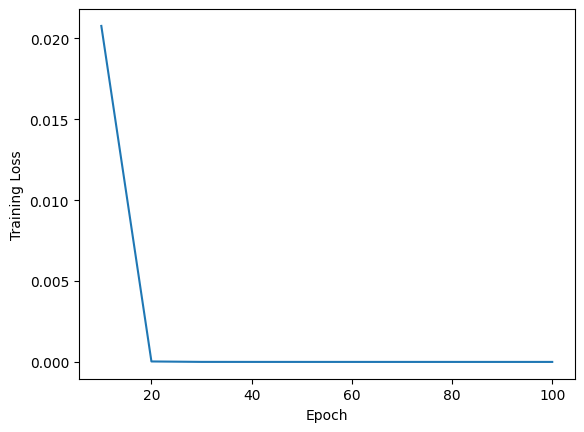

In [427]:
plt.plot(log['Epoch'],log['Training Loss'])
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()

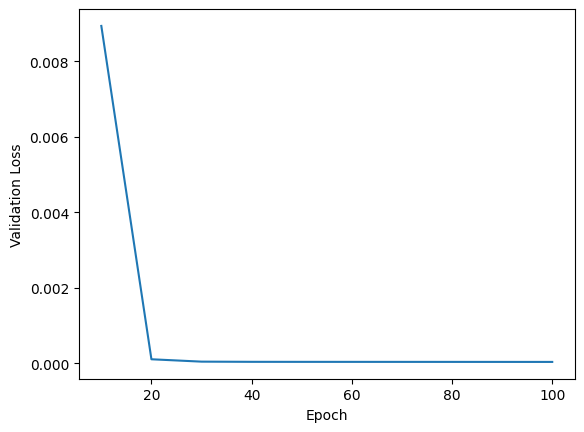

In [428]:
plt.plot(log['Epoch'],log['Validation Loss'])
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.show()

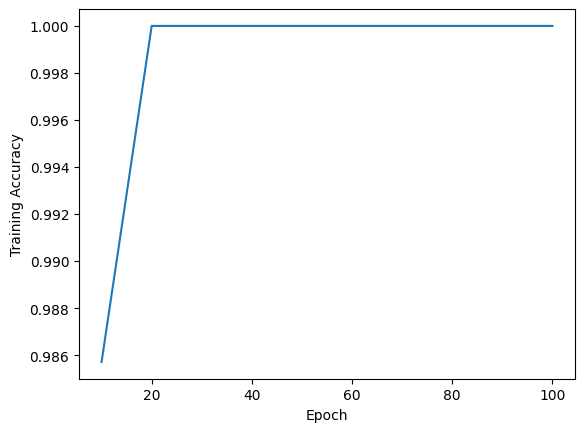

In [429]:
plt.plot(log['Epoch'],log['Training Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.show()

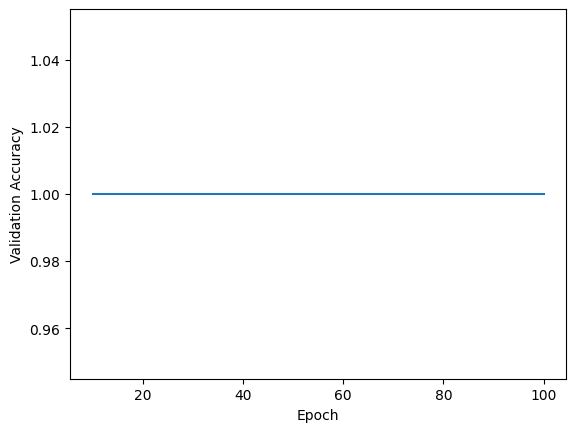

In [430]:
plt.plot(log['Epoch'],log['Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.show()

Accuracy Score:1.0
Precision Score:1.0
Recall Score:1.0
F1 Score:1.0


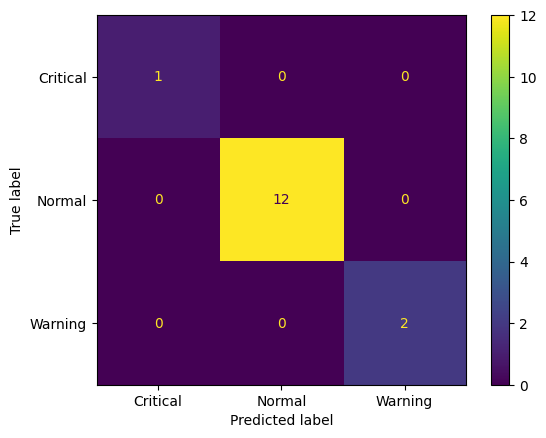

In [431]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import make_scorer,precision_score,recall_score,accuracy_score,f1_score
model.eval()
y_true_list=[]
y_pred_list=[]
with torch.no_grad():
    for features,labels in testloader:
        features=features.to(device)
        labels=labels.to(device)
        output=model(features)
        _,y_pred=torch.max(output,1)
        y_true_list.extend(labels)
        y_pred_list.extend(y_pred)
    print(f'Accuracy Score:{accuracy_score(y_true_list,y_pred_list)}')
    print(f"Precision Score:{precision_score(y_true_list,y_pred_list,average='weighted')}")
    print(f"Recall Score:{recall_score(y_true_list,y_pred_list,average='weighted')}")
    print(f"F1 Score:{f1_score(y_true_list,y_pred_list,average='weighted')}")
cm=confusion_matrix(y_true_list,y_pred_list)
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_).plot()
